In [1]:
import numpy as np
import pandas as pd

import patpy

In [2]:
patpy.__version__

'0.15.3'

In [3]:
adata = patpy.datasets.combat_preprocessed()
adata

Downloading: 100%|██████████| 1.38G/1.38G [02:44<00:00, 8.43MB/s]


AnnData object with n_obs × n_vars = 783677 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

In [ ]:
adata = patpy.pp.subsample(adata, obs_category_col="")

In [4]:
adata.obs["sample_id"] = np.random.choice(np.arange(10), size=adata.n_obs)
adata.obs["sample_id"].value_counts()

sample_id
7    287
3    278
9    267
4    263
8    259
1    259
5    259
6    258
0    258
2    250
Name: count, dtype: int64

In [5]:
adata.obs["replicate"] = np.random.choice(["1", "2"], size=adata.n_obs)

In [6]:
adata.obs["sample_id_with_replicate"] = adata.obs["sample_id"].astype(str) + "_" + adata.obs["replicate"]
adata.obs["sample_id_with_replicate"].value_counts()

sample_id_with_replicate
3_2    146
7_1    145
4_2    144
7_2    142
9_1    142
8_1    140
2_1    136
1_1    136
0_1    134
5_1    134
3_1    132
6_1    131
6_2    127
9_2    125
5_2    125
0_2    124
1_2    123
8_2    119
4_1    119
2_2    114
Name: count, dtype: int64

In [7]:
from patpy.tl.sample_representation import CellGroupComposition, Pseudobulk

In [8]:
classes = Pseudobulk, CellGroupComposition

sample_rep_methods = []
distances = []

for class_ in classes:
    instance = class_(sample_key="sample_id_with_replicate", cell_group_key="louvain", layer="X_pca")
    instance.prepare_anndata(adata)

    distances_df = pd.DataFrame(
        instance.calculate_distance_matrix(force=True), index=instance.samples, columns=instance.samples
    )
    distances.append(distances_df)
    sample_rep_methods.append(instance)

/Users/vladimir.shitov/Documents/programming/patpy/src/patpy/tl/sample_representation.py:1092: UserWarning: Using data from adata.obsm['X_pca']
  data = self._get_data()


In [9]:
for class_, distances_df in zip(classes, distances):
    print(class_.__name__, patpy.tl.evaluation.replicate_robustness(distances_df))

Pseudobulk 0.4194444444444445
CellGroupComposition 0.4722222222222222


In [10]:
distances_df

,7_1,3_1,6_1,6_2,0_1,4_2,8_2,9_2,1_2,5_2,4_1,3_2,7_2,5_1,9_1,2_2,2_1,1_1,8_1,0_2
7_1,0.000000,0.117007,0.136217,0.053079,0.107412,0.073344,0.091978,0.114503,0.093014,0.075324,0.072326,0.073775,0.107598,0.109858,0.150624,0.087535,0.100869,0.121221,0.052084,0.059542
3_1,0.117007,0.000000,0.183009,0.113328,0.118983,0.099415,0.085171,0.126323,0.146510,0.115579,0.096108,0.113315,0.104457,0.063065,0.147171,0.123200,0.148868,0.092556,0.078671,0.116707
6_1,0.136217,0.183009,0.000000,0.150582,0.187793,0.127531,0.173521,0.158220,0.077865,0.105681,0.140941,0.104846,0.147375,0.203783,0.138191,0.137535,0.109100,0.179023,0.143948,0.107300
6_2,0.053079,0.113328,0.150582,0.000000,0.141067,0.108335,0.120772,0.093916,0.122027,0.060622,0.095313,0.094296,0.139050,0.122756,0.169297,0.120332,0.125791,0.119867,0.057039,0.062350
0_1,0.107412,0.118983,0.187793,0.141067,0.000000,0.074062,0.054604,0.167346,0.130567,0.149929,0.086894,0.124231,0.075749,0.073119,0.139285,0.096821,0.113922,0.114395,0.096461,0.130902
4_2,0.073344,0.099415,0.127531,0.108335,0.074062,0.000000,0.059588,0.133069,0.068707,0.094214,0.047261,0.077135,0.044380,0.088209,0.104379,0.057528,0.088739,0.102644,0.072089,0.088901
8_2,0.091978,0.085171,0.173521,0.120772,0.054604,0.059588,0.000000,0.154651,0.123324,0.128810,0.076096,0.097759,0.073462,0.053180,0.140034,0.090028,0.124500,0.113260,0.072391,0.108742
9_2,0.114503,0.126323,0.158220,0.093916,0.167346,0.133069,0.154651,0.000000,0.123967,0.078384,0.095234,0.149167,0.136864,0.143060,0.125638,0.112618,0.114855,0.080840,0.112763,0.123757
1_2,0.093014,0.146510,0.077865,0.122027,0.130567,0.068707,0.123324,0.123967,0.000000,0.083017,0.074867,0.096239,0.083169,0.149150,0.088240,0.065791,0.067827,0.125094,0.110287,0.098422
5_2,0.075324,0.115579,0.105681,0.060622,0.149929,0.094214,0.128810,0.078384,0.083017,0.000000,0.081971,0.088654,0.119908,0.136972,0.129767,0.102245,0.104042,0.108698,0.076689,0.063873


/Users/vladimir.shitov/miniconda3/envs/sample_representation/lib/python3.11/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


<Axes: xlabel='MDS_0', ylabel='MDS_1'>

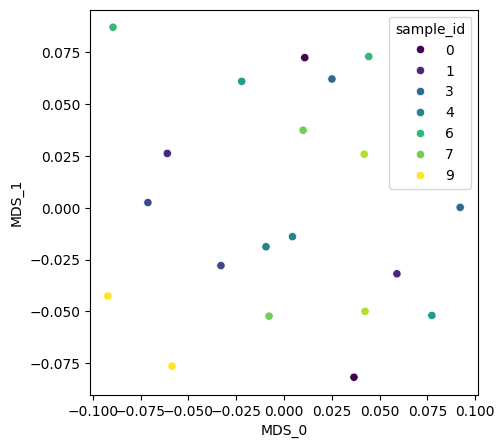

In [12]:
instance.plot_embedding("MDS", metadata_cols=["sample_id"])